# 05. User 序列长度 & 稠密度分析（决定 SFT 序列截断策略）

> 对应 `analysis_plan.md` §2.5。**这是 Stage-C（用户历史 → next SID）主任务样本构造的最直接依据**。

## 目的

1. **每域 primary 序列的长度分布**（P50/P90/P99/max）→ 决定 prompt 里每域最多拼多少条历史，避免超过模型 max_position。
2. **每域 primary 序列的非空率** → 决定 SFT 样本必须要求哪些域至少有历史。
3. **反馈标签的正样本率**（例如 `video_like_list==1` / `ec_cvr_label_list ≠ 0` / `outer_loop_click`）→ 决定正负样本采样权重与 loss reweighting。
4. **时间跨度**（`*_ts_list` 的 max−min，天为单位）→ 决定是否可用最近 N 天切分做 leakage-safe 的验证集。

## 输入 / 输出

**输入**：`OneReason_UserProfile/*.parquet`（50 万用户、10 parquet、8.56 GB）

**输出**（`analysis/outputs/user_seq/`）：
- `seq_length_summary.csv` —— 每 domain × 每 primary sequence 的 P50/P90/P99/max/非空率
- `label_pos_rate.csv` —— 每 primary 序列上，各反馈标签的正样本率
- `time_span.csv` —— 每域的时间跨度（天）
- `len_hist_{domain}.png` —— 长度直方图
- `_cache.pkl` —— 中间统计缓存（供后续 notebook 复用）

## 关键设计

8.56 GB 表**只读长度和标签均值**（不展开 pid list），用 `pyarrow.compute.list_value_length` 直接从 arrow ChunkedArray 取长度，比 `to_pandas + map(len)` 快 10 倍以上。

In [1]:
# ============ 配置 & imports ============
import os, pickle, time
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import pyarrow.compute as pc
import matplotlib.pyplot as plt

# ---- macOS 中文字体 ----
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Songti SC', 'STHeiti', 'Hiragino Sans GB', 'PingFang SC', 'Heiti SC', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

PROJECT_ROOT = Path('/Users/cjs/Desktop/MY/explore_llm_rec')
USER_DIR     = PROJECT_ROOT / 'dataset_rec_all' / 'data' / 'OneReason_UserProfile'
OUT_DIR      = PROJECT_ROOT / 'analysis' / 'outputs' / 'user_seq'
OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_PATH   = OUT_DIR / '_cache.pkl'

USE_CACHE = True
SAMPLE_FRAC = 1.0   # 全量 50w 完全能扫；试跑改 0.05

# ---- 字段分组（按 domain 组织）----
# primary sequences: 每域内是「一等公民」序列；后面按 domain 汇总
PRIMARY = {
    'video/video': [
        'video_sampled_pid_list',                # 当前点击
        'video_history_sampled_pid_list',        # 历史展示
    ],
    'goods': [
        'ec_item_id_list',                       # 转化 primary（cvr 对齐）
        'ec_good_click_item_id_list_extend',     # 近期点击
        'ec_good_order_item_id_list_extend',     # 近期购买
        'ec_colossus_rs_item_id_list',           # 近期展示
    ],
    'live': [
        'live_hist_author_id_list',
    ],
    'video/ad': [
        'outer_loop_history_action_pid_list_pos',      # 转化
        'outer_loop_history_action_pid_list_click',    # 点击
        'outer_loop_deep_target_pid',                  # 深度转化目标
    ],
}

# feedback labels：与哪个 primary 序列对齐（同长度）
# key = primary 序列, value = list of (label_field, positive_condition)
# positive_condition: 'gt0' / 'eq1' / 'eq2plus'
FEEDBACK = {
    'video_sampled_pid_list': [
        ('video_like_list', 'eq1'),
        ('video_comment_list', 'eq1'),
        ('video_forward_list', 'eq1'),
        ('video_collect_list', 'eq1'),
        ('video_neg_feedback_list', 'eq1'),
        ('video_play_done_list', 'eq1'),
    ],
    'video_history_sampled_pid_list': [
        ('video_history_like_list', 'eq1'),
        ('video_history_comment_list', 'eq1'),
        ('video_history_forward_list', 'eq1'),
        ('video_history_collect_list', 'eq1'),
        ('video_history_neg_feedback_list', 'eq1'),
        ('video_history_play_done_list', 'eq1'),
    ],
    'ec_item_id_list': [
        ('ec_cvr_label_list', 'gt0'),   # 转化 label 非零即视为正
    ],
    'ec_colossus_rs_item_id_list': [
        ('ec_colossus_rs_is_click_list', 'eq1'),
        ('ec_colossus_rs_is_cart_list',  'eq1'),
        ('ec_colossus_rs_is_buy_list',   'eq1'),
    ],
    'live_hist_author_id_list': [
        ('live_hist_valid_play_cnt_list', 'gt0'),
        ('live_hist_like_cnt_list',       'gt0'),
        ('live_hist_comment_cnt_list',    'gt0'),
        ('live_hist_follow_author_cnt_list', 'eq1'),
        ('live_hist_reduce_similar_cnt_list', 'gt0'),
    ],
}

# 时间戳字段（对齐到 primary，用于时间跨度分析）
TS_FIELDS = {
    'video_sampled_pid_list':               ('video_ts_list', 'ms'),
    'video_history_sampled_pid_list':       ('video_history_ts_list', 'ms'),
    'ec_item_id_list':                      ('ec_time_ms_list', 'ms'),
    'live_hist_author_id_list':             ('live_hist_timestamp_list', 'date_str'),
    'outer_loop_history_action_pid_list_pos':     ('outer_loop_history_action_pid_list_pos_ts', 'ms'),
    'outer_loop_history_action_pid_list_click':   ('outer_loop_history_action_pid_list_click_ts', 'ms'),
    'outer_loop_deep_target_pid':                 ('outer_loop_deep_target_pid_ts', 'ms'),
}

print('User dir  :', USER_DIR)
print('Output dir:', OUT_DIR)
parquet_files = sorted(USER_DIR.glob('part-*.parquet'))
print(f'#parquet  : {len(parquet_files)}')

User dir  : /Users/cjs/Desktop/MY/explore_llm_rec/dataset_rec_all/data/OneReason_UserProfile
Output dir: /Users/cjs/Desktop/MY/explore_llm_rec/analysis/outputs/user_seq
#parquet  : 10


## 单遍扫描：一次收集所有需要的中间统计

扫描每个 parquet 时，对每个 primary 序列字段 :
- 用 `pc.list_value_length()` 拿长度数组 → 计入 `lens_by_field[field]`
- 对配套 feedback 字段：把 flat values 拿出来算正样本比例（不需要对齐 pid，因为均值就是我们要的）
- 对时间戳字段：读第一个和最后一个（假定单调，取 span），或读全部再算 min/max

> 全部只操作 arrow buffer，避免 pandas conversion 开销。

In [2]:
def _flat_np_int(chunked_array):
    """list<int64> ChunkedArray -> flat np.int64 (values only, drop nulls & empty)."""
    if chunked_array is None:
        return np.array([], dtype=np.int64)
    values = chunked_array.combine_chunks().values  # arrow int64 array
    return np.asarray(values, dtype=np.int64)


def _flat_np_float(chunked_array):
    if chunked_array is None:
        return np.array([], dtype=np.float32)
    values = chunked_array.combine_chunks().values
    return np.asarray(values, dtype=np.float32)


def _lens(tbl_col):
    """return int32 numpy array of list lengths per row (0 for null lists)."""
    if tbl_col is None:
        return np.array([], dtype=np.int32)
    lens = pc.list_value_length(tbl_col).fill_null(0)
    return np.asarray(lens, dtype=np.int32)


def _pos_rate(fld, cond):
    if fld is None:
        return None
    if cond == 'eq1':
        arr = _flat_np_float(fld) if fld.type.value_type in (pa.float32(), pa.float64()) else _flat_np_int(fld)
        if arr.size == 0: return None
        return {'n_labels': int(arr.size), 'pos_rate': float((arr == 1).mean())}
    if cond == 'gt0':
        arr = _flat_np_int(fld) if fld.type.value_type not in (pa.float32(), pa.float64()) else _flat_np_float(fld)
        if arr.size == 0: return None
        return {'n_labels': int(arr.size), 'pos_rate': float((arr > 0).mean())}
    return None


def _ts_span_ms(chunked_array):
    """返回 (min_ms, max_ms) 全局 —— 遍历一次求 min/max。"""
    arr = _flat_np_int(chunked_array)
    if arr.size == 0:
        return (None, None)
    # 部分 ts 会用 0 代表 padding；过滤掉
    arr = arr[arr > 0]
    if arr.size == 0:
        return (None, None)
    return (int(arr.min()), int(arr.max()))


def scan_user_profile(files, sample_frac=1.0):
    all_primary_fields = [f for lst in PRIMARY.values() for f in lst]
    all_feedback_fields = list({f for lst in FEEDBACK.values() for (f, _) in lst})
    all_ts_fields = list({t[0] for t in TS_FIELDS.values()})
    read_cols = list(set(all_primary_fields + all_feedback_fields + all_ts_fields))
    print(f'reading {len(read_cols)} columns')

    lens_by_field  = defaultdict(list)   # field -> list of np.int32
    pos_by_field   = defaultdict(lambda: [0, 0])   # field -> [n_pos, n_total]
    ts_by_field    = defaultdict(lambda: [None, None])  # field -> [min, max]
    total_rows = 0

    t0 = time.time()
    for i, fp in enumerate(files):
        if fp.stat().st_size == 0:
            continue
        tbl = pq.read_table(fp, columns=read_cols)
        n_rows = tbl.num_rows
        total_rows += n_rows

        # primary 长度
        for f in all_primary_fields:
            if f in tbl.column_names:
                lens_by_field[f].append(_lens(tbl.column(f)))

        # feedback 正样本率
        for f in all_feedback_fields:
            if f not in tbl.column_names:
                continue
            col = tbl.column(f)
            # find its condition (any of primary that references it)
            cond = None
            for _, lst in FEEDBACK.items():
                for (ff, cc) in lst:
                    if ff == f:
                        cond = cc; break
                if cond: break
            r = _pos_rate(col, cond)
            if r is not None:
                pos_by_field[f][0] += int(r['pos_rate'] * r['n_labels'])
                pos_by_field[f][1] += r['n_labels']

        # 时间戳
        for f in all_ts_fields:
            if f not in tbl.column_names:
                continue
            col = tbl.column(f)
            if pa.types.is_list(col.type) and pa.types.is_string(col.type.value_type):
                # live_hist_timestamp_list 是 date-string, 特殊处理
                s_arr = col.combine_chunks().values
                s_np = np.asarray(s_arr, dtype=object)
                s_np = s_np[np.array([bool(x) for x in s_np])]
                if s_np.size == 0: continue
                # 假设格式是 'YYYY-MM-DD' 或 'YYYYMMDD'，对字符串直接 min/max
                mn, mx = str(s_np.min()), str(s_np.max())
                if ts_by_field[f][0] is None or mn < ts_by_field[f][0]:
                    ts_by_field[f][0] = mn
                if ts_by_field[f][1] is None or mx > ts_by_field[f][1]:
                    ts_by_field[f][1] = mx
            else:
                mn, mx = _ts_span_ms(col)
                if mn is None: continue
                if ts_by_field[f][0] is None or mn < ts_by_field[f][0]:
                    ts_by_field[f][0] = mn
                if ts_by_field[f][1] is None or mx > ts_by_field[f][1]:
                    ts_by_field[f][1] = mx

        print(f'  parquet {i+1}/{len(files)} done  rows so far={total_rows:,}  elapsed={time.time()-t0:.1f}s')

    # 拼接 lens_by_field
    lens_final = {f: np.concatenate(v) for f, v in lens_by_field.items()}
    return {
        'lens':       lens_final,
        'pos':        {f: tuple(v) for f, v in pos_by_field.items()},
        'ts':         {f: tuple(v) for f, v in ts_by_field.items()},
        'total_rows': total_rows,
    }


if USE_CACHE and CACHE_PATH.exists():
    print(f'[cache] loading {CACHE_PATH}')
    with open(CACHE_PATH, 'rb') as f:
        stats = pickle.load(f)
    print('[cache] loaded.')
else:
    stats = scan_user_profile(parquet_files, SAMPLE_FRAC)
    with open(CACHE_PATH, 'wb') as f:
        pickle.dump(stats, f)
    print(f'[cache] saved to {CACHE_PATH}')

print(f'\ntotal_rows: {stats["total_rows"]:,}')

reading 38 columns
  parquet 1/10 done  rows so far=50,000  elapsed=3.2s
  parquet 2/10 done  rows so far=100,000  elapsed=5.6s
  parquet 3/10 done  rows so far=150,000  elapsed=8.2s
  parquet 4/10 done  rows so far=200,000  elapsed=10.6s
  parquet 5/10 done  rows so far=250,000  elapsed=13.0s
  parquet 6/10 done  rows so far=300,000  elapsed=15.4s
  parquet 7/10 done  rows so far=350,000  elapsed=17.3s
  parquet 8/10 done  rows so far=400,000  elapsed=19.9s
  parquet 9/10 done  rows so far=450,000  elapsed=22.3s
  parquet 10/10 done  rows so far=500,000  elapsed=25.1s
[cache] saved to /Users/cjs/Desktop/MY/explore_llm_rec/analysis/outputs/user_seq/_cache.pkl

total_rows: 500,000


## §2.5.1 主序列长度分布（每域每 primary 一行）

In [3]:
rows = []
for domain, fields in PRIMARY.items():
    for f in fields:
        arr = stats['lens'].get(f)
        if arr is None:
            continue
        n = arr.size
        n_nonempty = int((arr > 0).sum())
        nz = arr[arr > 0]
        rows.append({
            'domain':      domain,
            'field':       f,
            'n_users':     n,
            'nonempty_%':  round(n_nonempty / max(1, n) * 100, 2),
            'p50':         int(np.percentile(nz, 50)) if nz.size else 0,
            'p90':         int(np.percentile(nz, 90)) if nz.size else 0,
            'p95':         int(np.percentile(nz, 95)) if nz.size else 0,
            'p99':         int(np.percentile(nz, 99)) if nz.size else 0,
            'max':         int(nz.max()) if nz.size else 0,
            'mean':        round(float(nz.mean()), 1) if nz.size else 0.0,
            'total_events': int(nz.sum()) if nz.size else 0,
        })
seqlen_df = pd.DataFrame(rows)
seqlen_df.to_csv(OUT_DIR / 'seq_length_summary.csv', index=False)
print('saved:', OUT_DIR / 'seq_length_summary.csv')
seqlen_df

saved: /Users/cjs/Desktop/MY/explore_llm_rec/analysis/outputs/user_seq/seq_length_summary.csv


,domain,field,n_users,nonempty_%,p50,p90,p95,p99,max,mean,total_events
0,video/video,video_sampled_pid_list,500000,95.07,2,7,10,18,522,3.5,1656218
1,video/video,video_history_sampled_pid_list,500000,100.00,649,1558,1950,2946,38041,818.8,409416641
2,goods,ec_item_id_list,500000,0.19,1,1,2,3,6,1.1,1049
3,goods,ec_good_click_item_id_list_extend,500000,69.06,322,371,371,371,371,234.5,80961694
4,goods,ec_good_order_item_id_list_extend,500000,51.94,37,269,291,300,301,81.5,21155399
5,goods,ec_colossus_rs_item_id_list,500000,70.21,498,500,500,500,500,444.8,156152303
6,live,live_hist_author_id_list,500000,71.93,8,148,324,1652,83679,98.9,35580635
7,video/ad,outer_loop_history_action_pid_list_pos,500000,53.02,4,28,54,157,2090,13.2,3490775
8,video/ad,outer_loop_history_action_pid_list_click,500000,71.09,20,96,183,1318,18892,73.7,26193748
9,video/ad,outer_loop_deep_target_pid,500000,1.50,1,2,2,4,9,1.2,8851


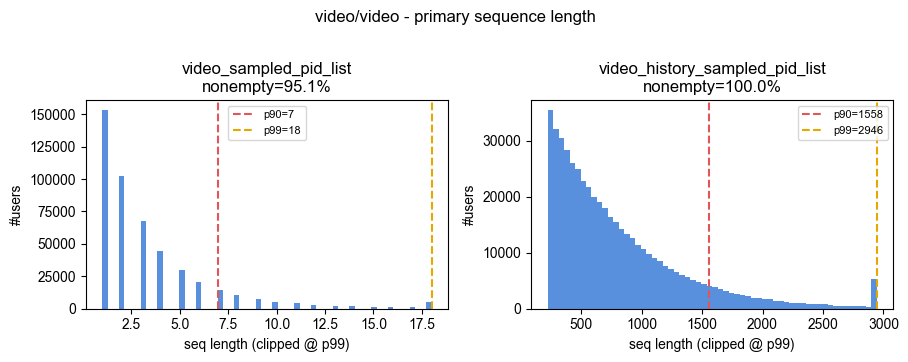

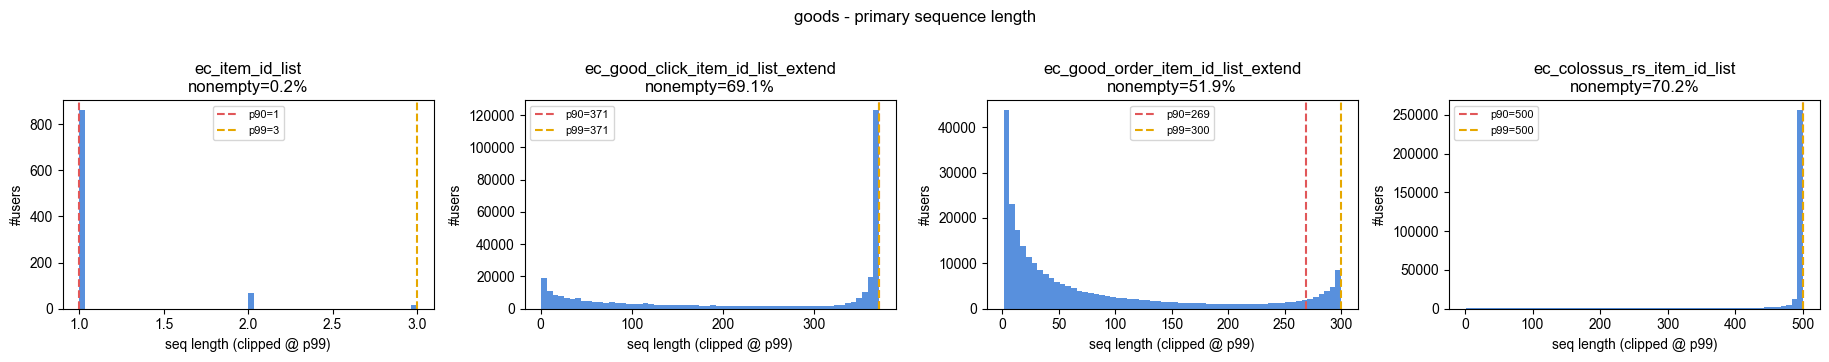

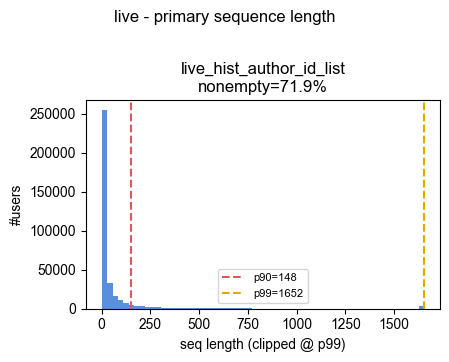

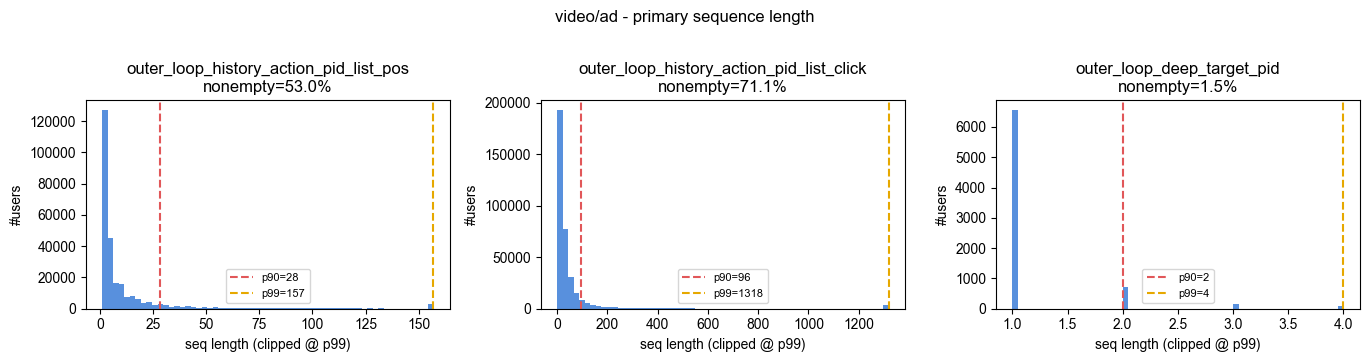

In [4]:
# 每 domain 一张图：primary 长度直方图（clip 到 P99 避免长尾拉爆坐标轴）
for domain, fields in PRIMARY.items():
    n = len(fields)
    fig, axes = plt.subplots(1, n, figsize=(4.6 * n, 3.5), squeeze=False)
    for i, f in enumerate(fields):
        arr = stats['lens'].get(f)
        ax = axes[0][i]
        if arr is None or (arr > 0).sum() == 0:
            ax.set_title(f'{f}\n(no data)')
            continue
        nz = arr[arr > 0]
        clip = int(np.percentile(nz, 99))
        ax.hist(nz.clip(0, clip), bins=60, color='#3b7dd8', alpha=0.85)
        ax.axvline(np.percentile(nz, 90), color='#e15759', ls='--', label=f'p90={int(np.percentile(nz, 90))}')
        ax.axvline(np.percentile(nz, 99), color='#e6a800', ls='--', label=f'p99={clip}')
        ax.set_title(f'{f}\nnonempty={((arr>0).sum()/arr.size*100):.1f}%')
        ax.set_xlabel('seq length (clipped @ p99)'); ax.set_ylabel('#users'); ax.legend(fontsize=8)
    plt.suptitle(f'{domain} - primary sequence length', y=1.02)
    plt.tight_layout()
    safe = domain.replace('/', '_')
    plt.savefig(OUT_DIR / f'len_hist_{safe}.png', dpi=110, bbox_inches='tight')
    plt.show()

## §2.5.2 反馈标签正样本率

对每个反馈标签算全体 flat 均值：
- `eq1`：视频/直播互动 (like/comment/forward/collect/negfb/playdone/follow)
- `gt0`：整数计数类（cvr_label / play_cnt / like_cnt 等）

In [5]:
label_rows = []
for primary, feats in FEEDBACK.items():
    for f, cond in feats:
        v = stats['pos'].get(f)
        if v is None or v[1] == 0:
            continue
        n_pos, n_total = v
        label_rows.append({
            'primary':    primary,
            'label':      f,
            'condition':  cond,
            'n_events':   n_total,
            'n_positive': n_pos,
            'pos_rate_%': round(n_pos / n_total * 100, 3),
        })
label_df = pd.DataFrame(label_rows)
label_df.to_csv(OUT_DIR / 'label_pos_rate.csv', index=False)
print('saved:', OUT_DIR / 'label_pos_rate.csv')
label_df.sort_values('pos_rate_%', ascending=True)

saved: /Users/cjs/Desktop/MY/explore_llm_rec/analysis/outputs/user_seq/label_pos_rate.csv


,primary,label,condition,n_events,n_positive,pos_rate_%
10,video_history_sampled_pid_list,video_history_neg_feedback_list,eq1,409416641,0,0.000
4,video_sampled_pid_list,video_neg_feedback_list,eq1,1656218,0,0.000
20,live_hist_author_id_list,live_hist_reduce_similar_cnt_list,gt0,35580635,17918,0.050
14,ec_colossus_rs_item_id_list,ec_colossus_rs_is_cart_list,eq1,156152303,287854,0.184
8,video_history_sampled_pid_list,video_history_forward_list,eq1,409416641,1640356,0.401
2,video_sampled_pid_list,video_forward_list,eq1,1656218,8335,0.503
9,video_history_sampled_pid_list,video_history_collect_list,eq1,409416641,2749555,0.672
3,video_sampled_pid_list,video_collect_list,eq1,1656218,15671,0.946
7,video_history_sampled_pid_list,video_history_comment_list,eq1,409416641,4566847,1.115
1,video_sampled_pid_list,video_comment_list,eq1,1656218,20844,1.259


## §2.5.3 时间跨度（决定验证集时间切分点）

In [6]:
def _fmt_ms(x):
    if x is None: return None
    if isinstance(x, str): return x  # date_str
    return pd.Timestamp(x, unit='ms').strftime('%Y-%m-%d %H:%M:%S')


def _span_days(a, b):
    if a is None or b is None:
        return None
    if isinstance(a, str):
        # try parse
        try:
            return (pd.to_datetime(b) - pd.to_datetime(a)).days
        except Exception:
            return None
    return (b - a) / (1000 * 60 * 60 * 24)


ts_rows = []
for primary, (ts_field, ts_type) in TS_FIELDS.items():
    v = stats['ts'].get(ts_field)
    if v is None:
        continue
    mn, mx = v
    ts_rows.append({
        'primary':      primary,
        'ts_field':     ts_field,
        'ts_type':      ts_type,
        'min':          _fmt_ms(mn) if ts_type == 'ms' else mn,
        'max':          _fmt_ms(mx) if ts_type == 'ms' else mx,
        'span_days':    round(_span_days(mn, mx), 2) if _span_days(mn, mx) is not None else None,
    })
ts_df = pd.DataFrame(ts_rows)
ts_df.to_csv(OUT_DIR / 'time_span.csv', index=False)
print('saved:', OUT_DIR / 'time_span.csv')
ts_df

saved: /Users/cjs/Desktop/MY/explore_llm_rec/analysis/outputs/user_seq/time_span.csv


,primary,ts_field,ts_type,min,max,span_days
0,video_sampled_pid_list,video_ts_list,ms,2026-02-04 15:42:15,2026-02-05 15:52:06,1.01
1,video_history_sampled_pid_list,video_history_ts_list,ms,2026-01-20 15:42:02,2026-02-04 15:52:23,15.01
2,ec_item_id_list,ec_time_ms_list,ms,2026-02-04 15:44:02,2026-02-05 15:41:51,1.00
3,live_hist_author_id_list,live_hist_timestamp_list,date_str,20250101,20260204,399.00
4,outer_loop_history_action_pid_list_pos,outer_loop_history_action_pid_list_pos_ts,ms,2025-12-06 16:00:01,2026-02-04 15:59:57,60.00
5,outer_loop_history_action_pid_list_click,outer_loop_history_action_pid_list_click_ts,ms,2025-12-06 16:00:00,2026-02-04 15:59:59,60.00
6,outer_loop_deep_target_pid,outer_loop_deep_target_pid_ts,ms,2026-02-04 16:00:04,2026-02-05 15:59:56,1.00


## §2.5.4 结论 & 对 SFT 的直接指导（结论抄进 report.md）

1. **每域最多拼多少条历史**（用 P90 而非 P99，因为 P99 里的极端用户会浪费大量 padding）：
   - `video/video`：如果 `video_history_sampled_pid_list` P90 数千，需要**抽样最近 K 条**（K=64 或 128），不能全拼。
   - `goods`：`ec_good_click_item_id_list_extend` 已被官方封顶（max=371），可以全拼但需截。
   - `live`：P90 若不长（数百级），全拼可能可行；P99 需截。
   - `video/ad`：`click` P90 数十至数百，`pos` P90 几十，`deep_target` 极少。
2. **Prompt token 预算分配**（假设 max_context = 4096）：
   - 系统 prompt + task hint ≈ 300 tokens
   - target SID ≈ 5 tokens
   - 剩余 3800 tokens 给用户历史 → 每 SID token 4 个（domain-begin 1 + s_a/s_b/s_c 3）→ **最多约 950 条历史 pid**。
   - 4 域按活跃度分配（每域 ~200~300 pid），加上反馈 hint 每条再多 1~2 token。
3. **正样本率极端稀疏的标签需要 upweight**：
   - 若 `outer_loop_deep_target_pid` 出现率 <2%（Stage-C 目标），loss 应对正例 `w = 1 / pos_rate` 加权，或使用 focal loss。
   - 若 `ec_cvr_label_list` 正样本率 < 1%，转化目标不能作为主 label，改用 `is_click / is_cart` 作 signal。
4. **时间切分**：如果 `span_days > 30`，可用 **最后 3 天** 做验证；若 span 较短（<7 天），必须做用户 leave-one-out 而不是时间切分。

### 产出物清单（`analysis/outputs/user_seq/`）
- `seq_length_summary.csv` —— 每域每 primary 长度分位
- `label_pos_rate.csv` —— 反馈标签正样本率
- `time_span.csv` —— 时间跨度
- `len_hist_{domain}.png` × 4
- `_cache.pkl`（供 §2.6 / §2.7 复用）